## Прогнозирование метрик

Чем активнее наши пользователи – тем выше нагрузка на сервера. И в последнее время нам всё чаще приходят жалобы, что приложение подвисает. 

**Цель проекта:** спрогнозировать, как изменится активность пользователей в течение ближайшего месяца. 

**Задачи:**
- Выберите основную метрику, которую вы планируете прогнозировать. Обоснуйте, почему именно она. Какое временное разрешение вы возьмёте? Будут ли какие-то дополнительные регрессоры, которые вы включите в модель?
- Постройте модель и провалидируйте её. Хватает ли у нас данных для бэктестинга с текущей задачей? Если нет, то определите, для какого горизонта прогнозирования у нас хватает данных.
- Выберите ту модель, которая кажется вам наиболее удачной (обоснуйте выбор). Проинтерпретируйте её результаты. Если есть какие-то важные ограничения по выводу – не забудьте их тоже указать.

Варианты метрик, которые можно рассмотреть для того, чтобы получить информацию об активности пользователей: DAU, количество просмотров (views), количество просмотров на пользователя, количество просмотренных постов. Эти метрики напрямую указывают на активность пользователей в приложении и, следовательно, о растущей нагрузке на сервер при увеличении активности пользователей. 

Следует взять временное разрешение день, так как необходимо проследить за пиками активности в приложении и выявить проблемы, а это можно сделать, если наблюдать за динамикой в рамках дня.

Можно добавить в качестве регрессора бинарную переменную, которая будет обозначать, является ли день активности выходным или рабочим днем.

In [1]:
import pandas as pd
import pandahouse as ph

In [2]:
connection = {'host': 'http://clickhouse.lab.karpov.courses:8123',
'database':'simulator_20260620',
'user':'student',
'password':'dpo_python_2020'
}

In [3]:
q = """
SELECT
    toDate(time) AS date,
    sum(action = 'view') AS views,
    count(action) AS actions,
    sum(action = 'like') AS likes,
    count(DISTINCT user_id) AS DAU,
    count(DISTINCT post_id) AS unique_posts
FROM {db}.feed_actions
WHERE date <= toDate(now()) - 1
GROUP BY date
ORDER BY date
"""

In [4]:
df = ph.read_clickhouse(q, connection=connection)

In [5]:
df['posts_per_user'] = df['views']/df['DAU']

# переменная, которая показывает количество просмотренных постов на пользователя

In [6]:
df['actions_per_user'] = df['actions']/df['DAU']

In [7]:
df

,date,views,actions,likes,DAU,unique_posts,posts_per_user,actions_per_user
0,2026-05-02,7603,9163,1560,878,89,8.659453,10.436219
1,2026-05-03,62770,75586,12816,2238,178,28.047364,33.773905
2,2026-05-04,105526,126484,20958,3105,191,33.985829,40.735588
3,2026-05-05,118996,142796,23800,3721,211,31.979575,38.375705
4,2026-05-06,174454,208958,34504,4617,214,37.785142,45.258393
...,...,...,...,...,...,...,...,...
124,2026-09-03,588981,709844,120863,18865,187,31.220832,37.627564
125,2026-09-04,624028,755837,131809,18394,190,33.925628,41.091497
126,2026-09-05,591327,716396,125069,18154,169,32.572821,39.462157
127,2026-09-06,503631,610623,106992,18167,184,27.722299,33.611659


Интересно рассмотреть динамику переменных во времени, чтобы зафиксировать влияние на них аномалий (как проведение флешмоба).

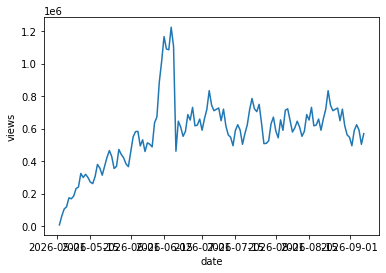

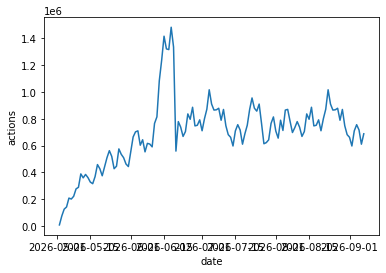

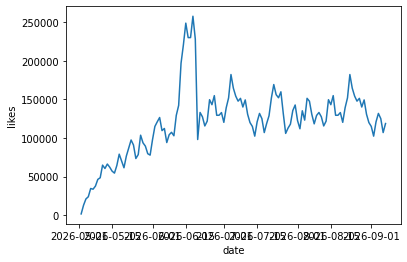

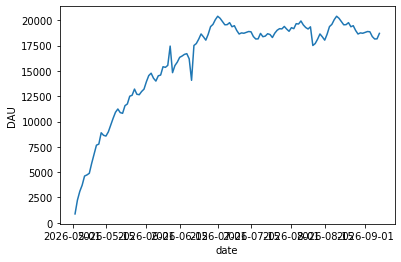

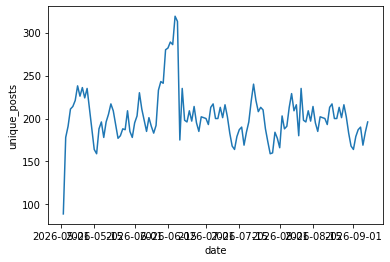

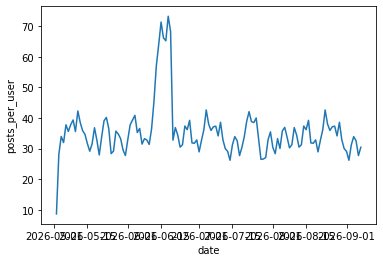

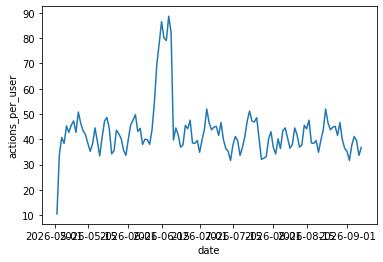

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in df.columns:
    if column != 'date':
        plt.figure(figsize=(6, 4))
        sns.lineplot(x="date", y=column, data=df)
        plt.show()

In [9]:
df.shape 

(129, 8)

У нас есть информация за период 75 дней.

По графикам на имеющихся у нас данных видно, что пик переменных с количеством сделанных постов, лайков, просмотров, количеством просмотренных постов на пользователя (и количеством действий в целом в расчете на пользователя) приходился на период проведения флешмоба. Он повлиял на эти показатели, и этот пик может влиять на прогноз. На DAU он не так сильно отразился (эта метрика меняется в общем тренде). Но аномальные изменения для DAU - это рекламная компания 11 июня и резкое падение активности 20 июня. 

Для предсказания возьму переменную actions_per_user.

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129 entries, 0 to 128
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   date              129 non-null    datetime64[ns]
 1   views             129 non-null    uint64        
 2   actions           129 non-null    uint64        
 3   likes             129 non-null    uint64        
 4   DAU               129 non-null    uint64        
 5   unique_posts      129 non-null    uint64        
 6   posts_per_user    129 non-null    float64       
 7   actions_per_user  129 non-null    float64       
dtypes: datetime64[ns](1), float64(2), uint64(5)
memory usage: 8.2 KB


In [11]:
df['day'] = df['date'].dt.weekday

In [12]:
df.head()

,date,views,actions,likes,DAU,unique_posts,posts_per_user,actions_per_user,day
0,2026-05-02,7603,9163,1560,878,89,8.659453,10.436219,5
1,2026-05-03,62770,75586,12816,2238,178,28.047364,33.773905,6
2,2026-05-04,105526,126484,20958,3105,191,33.985829,40.735588,0
3,2026-05-05,118996,142796,23800,3721,211,31.979575,38.375705,1
4,2026-05-06,174454,208958,34504,4617,214,37.785142,45.258393,2


In [13]:
df['is_weekend'] = df['day'].apply(lambda x: 1 if x in [5,6] else 0)

In [14]:
df

,date,views,actions,likes,DAU,unique_posts,posts_per_user,actions_per_user,day,is_weekend
0,2026-05-02,7603,9163,1560,878,89,8.659453,10.436219,5,1
1,2026-05-03,62770,75586,12816,2238,178,28.047364,33.773905,6,1
2,2026-05-04,105526,126484,20958,3105,191,33.985829,40.735588,0,0
3,2026-05-05,118996,142796,23800,3721,211,31.979575,38.375705,1,0
4,2026-05-06,174454,208958,34504,4617,214,37.785142,45.258393,2,0
...,...,...,...,...,...,...,...,...,...,...
124,2026-09-03,588981,709844,120863,18865,187,31.220832,37.627564,3,0
125,2026-09-04,624028,755837,131809,18394,190,33.925628,41.091497,4,0
126,2026-09-05,591327,716396,125069,18154,169,32.572821,39.462157,5,1
127,2026-09-06,503631,610623,106992,18167,184,27.722299,33.611659,6,1


### Построение модели

In [15]:
import orbit
from orbit.models import DLT
from orbit.diagnostics.plot import plot_predicted_data, plot_predicted_components

#### Первая модель - простейшая без регрессоров.

In [16]:
dlt = DLT(response_col="actions_per_user",
          date_col="date",
          seasonality=7,
          estimator="stan-map",
          n_bootstrap_draws=1000)

2026-09-08 12:53:14 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.


In [17]:
dlt.fit(df)

2026-09-08 12:53:14 - orbit - INFO - First time in running stan model:dlt. Expect 3 - 5 minutes for compilation.


In [18]:
future_df = dlt.make_future_df(periods=30) 

In [19]:
predicted_df = dlt.predict(df=future_df)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

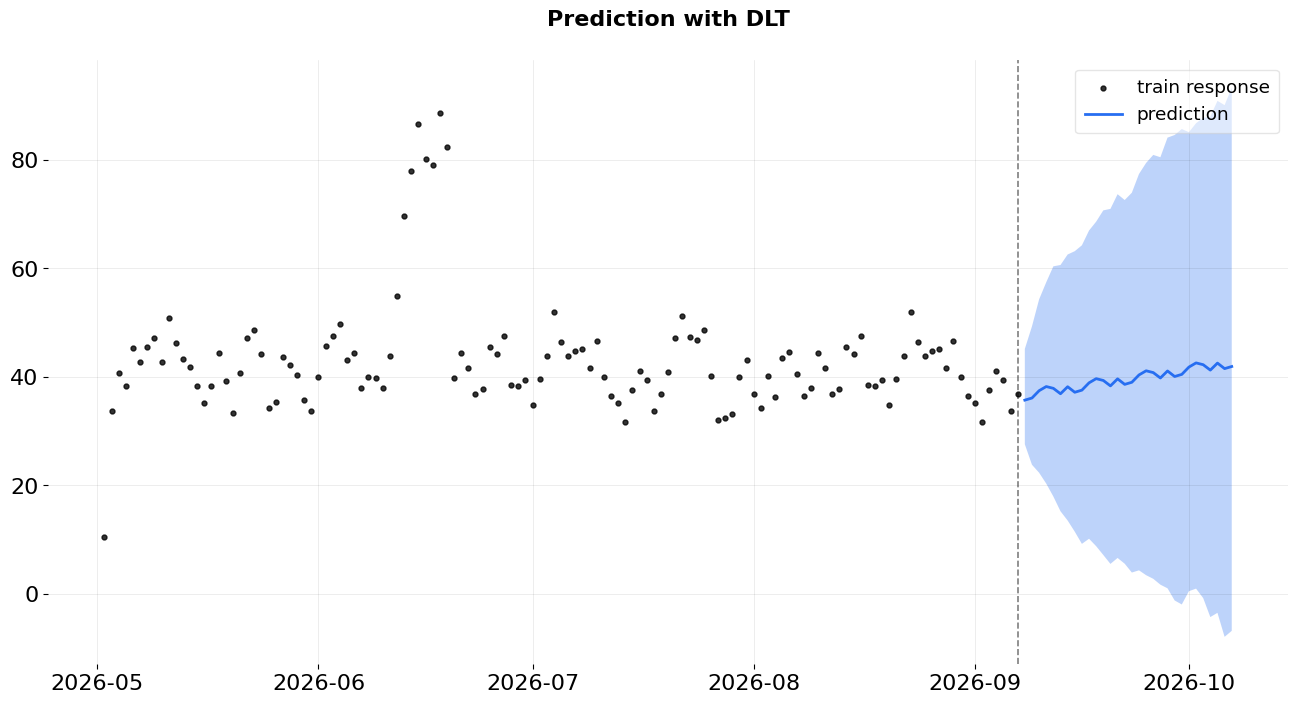

In [20]:
_ = plot_predicted_data(df,
                        predicted_df,
                        "date", 
                        'actions_per_user', 
                        title='Prediction with DLT') 

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

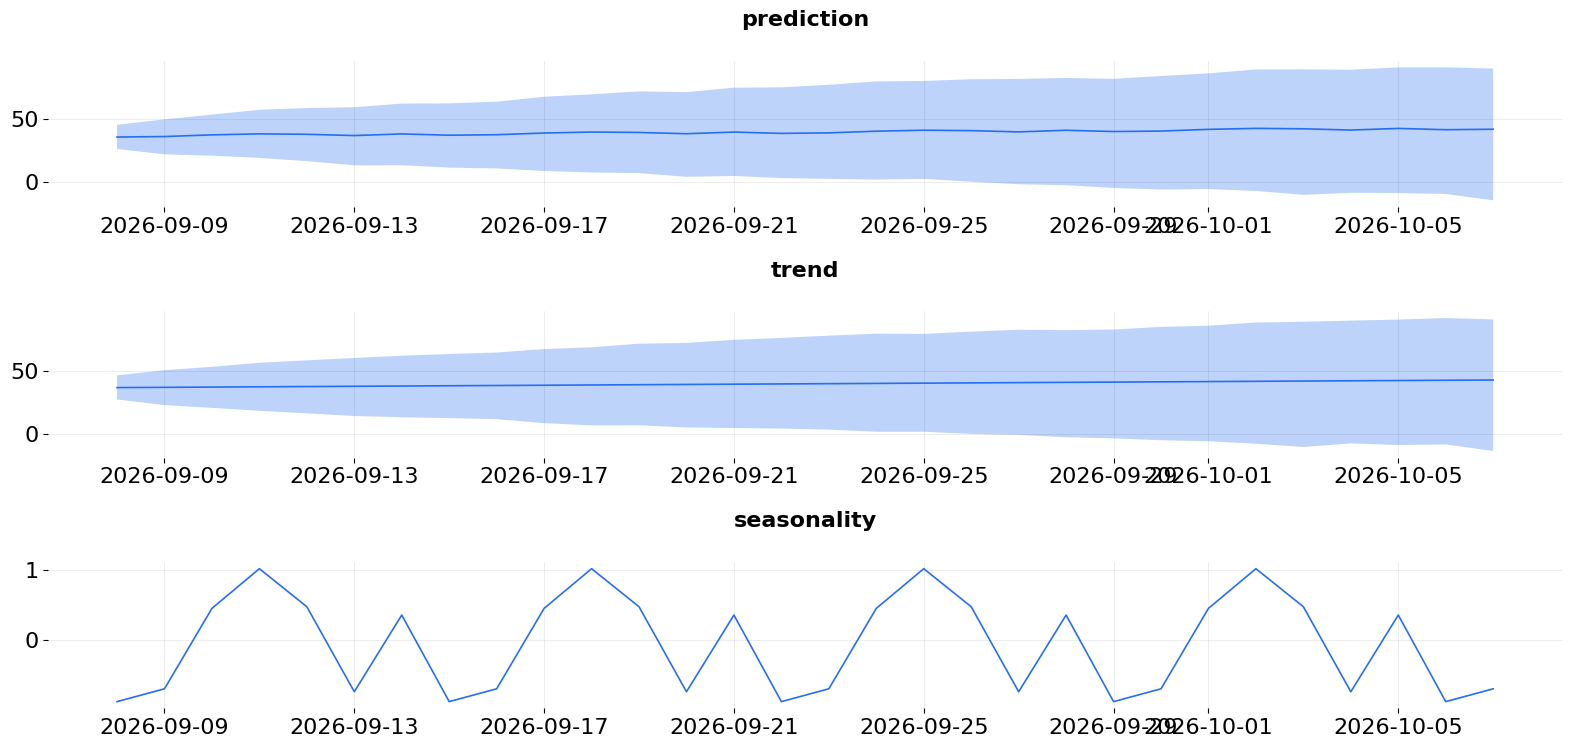

In [21]:
predicted_df = dlt.predict(df=future_df, 
                           decompose=True)

_ = plot_predicted_components(predicted_df, 
                              "date", 
                              plot_components=['prediction', 'trend', 'seasonality'])

In [22]:
dlt.get_bic()

865.2863831670354

#### Модель алгоритмом MCMC без регрессоров

In [23]:
dlt_mcmc = DLT(seasonality=7, response_col="actions_per_user",
               date_col="date",
               estimator="stan-mcmc",
               num_warmup=2000,
               num_sample=1000)

In [24]:
dlt_mcmc.fit(df)

2026-09-08 12:54:09 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

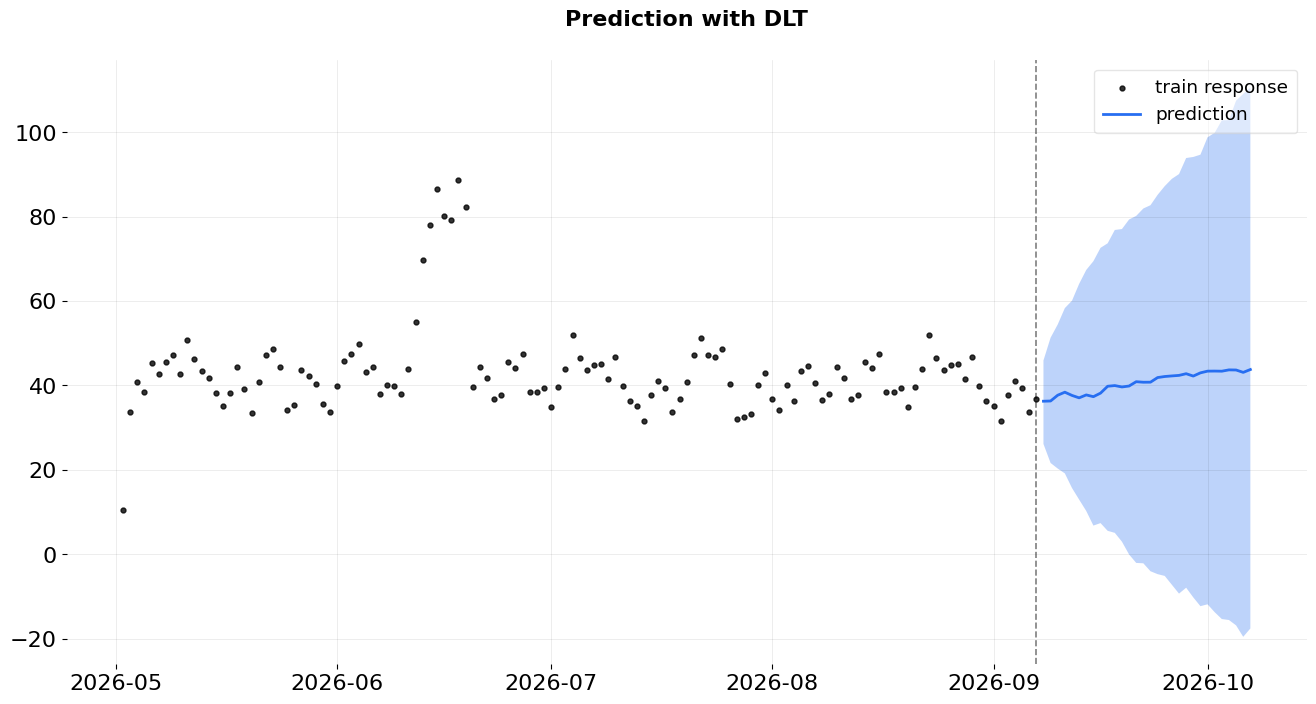

In [25]:
future_df = dlt_mcmc.make_future_df(periods=30) 
predicted_df = dlt_mcmc.predict(df=future_df)
_ = plot_predicted_data(df,
                        predicted_df,
                        "date", 
                        'actions_per_user', 
                        title='Prediction with DLT') 

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

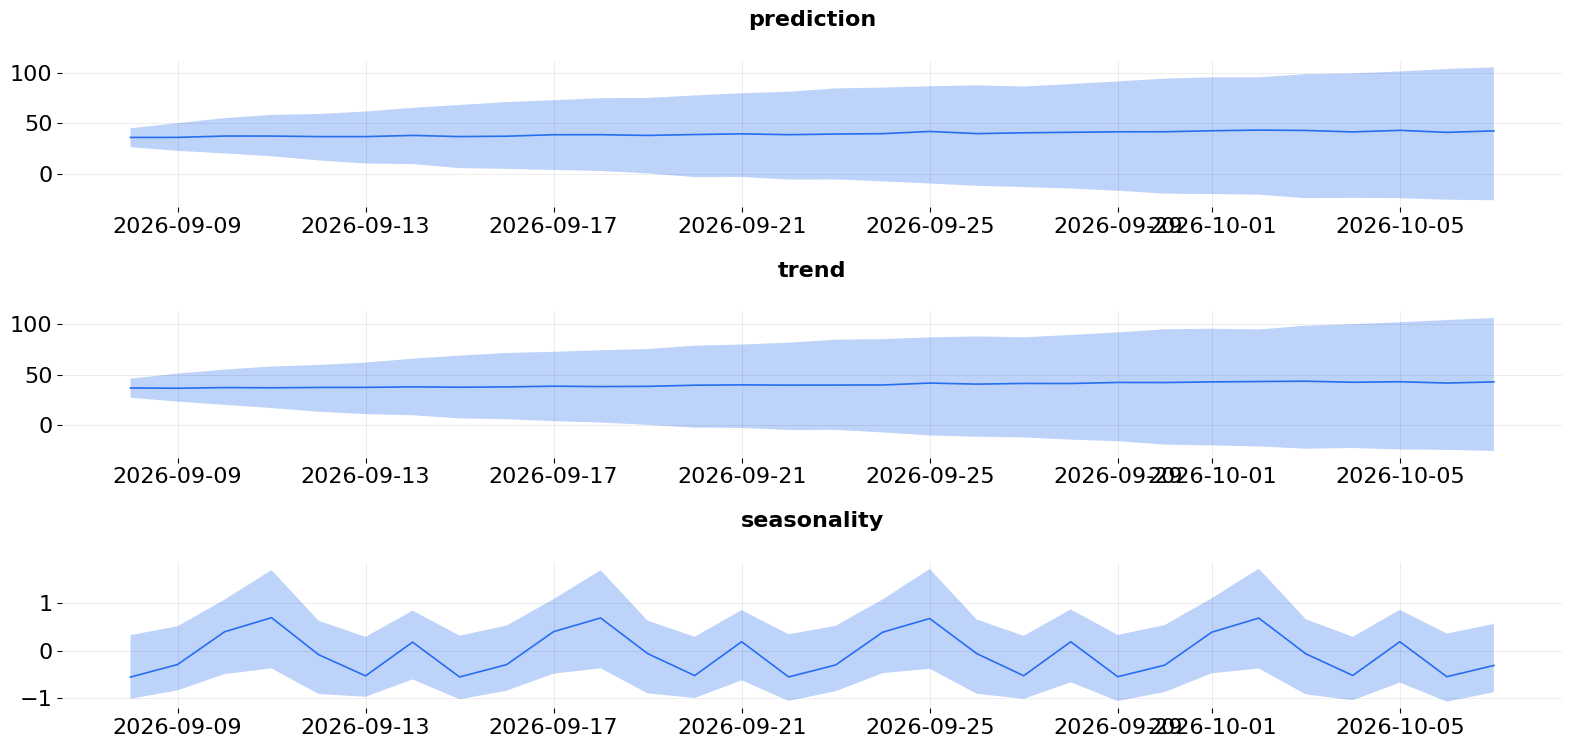

In [26]:
predicted_df = dlt_mcmc.predict(df=future_df, 
                           decompose=True)

_ = plot_predicted_components(predicted_df, 
                              "date", 
                              plot_components=['prediction', 'trend', 'seasonality'])

In [27]:
# модель, построенная методом MCMC
dlt_mcmc.fit_wbic(df=df)
dlt_mcmc.get_wbic()

2026-09-08 12:54:14 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 4.860, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

852.5721972604686

При использовании алгоритма MCMC информационный критерий ниже. В дальнейших моделях будет испоользован он. До MCMC они были построены с опорой на олгоритм MAP, значения информационного критерия были выше. Оставила вариант с алгоритмом MCMC. Также из моделей была исключена информация о типе сезонности (не совсем понятно, недельная ли она в принципе). Но были добавлены регрессоры о днях недели. 

#### Модель с регрессорами по дням недели (и без указания типа сезонности)

In [28]:
with_reg_model = DLT(response_col="actions_per_user",
                date_col="date", 
                estimator="stan-mcmc", # алгоритм map
                num_warmup=2000,
                num_sample=1000, 
                regressor_col=["is_weekend", "day"]
               )

In [29]:
with_reg_model.fit(df)

2026-09-08 12:54:18 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [30]:
future_df = with_reg_model.make_future_df(periods=30)
future_df['day'] = future_df['date'].dt.weekday
future_df['is_weekend'] = future_df['day'].apply(lambda x: 1 if x in [5,6] else 0)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

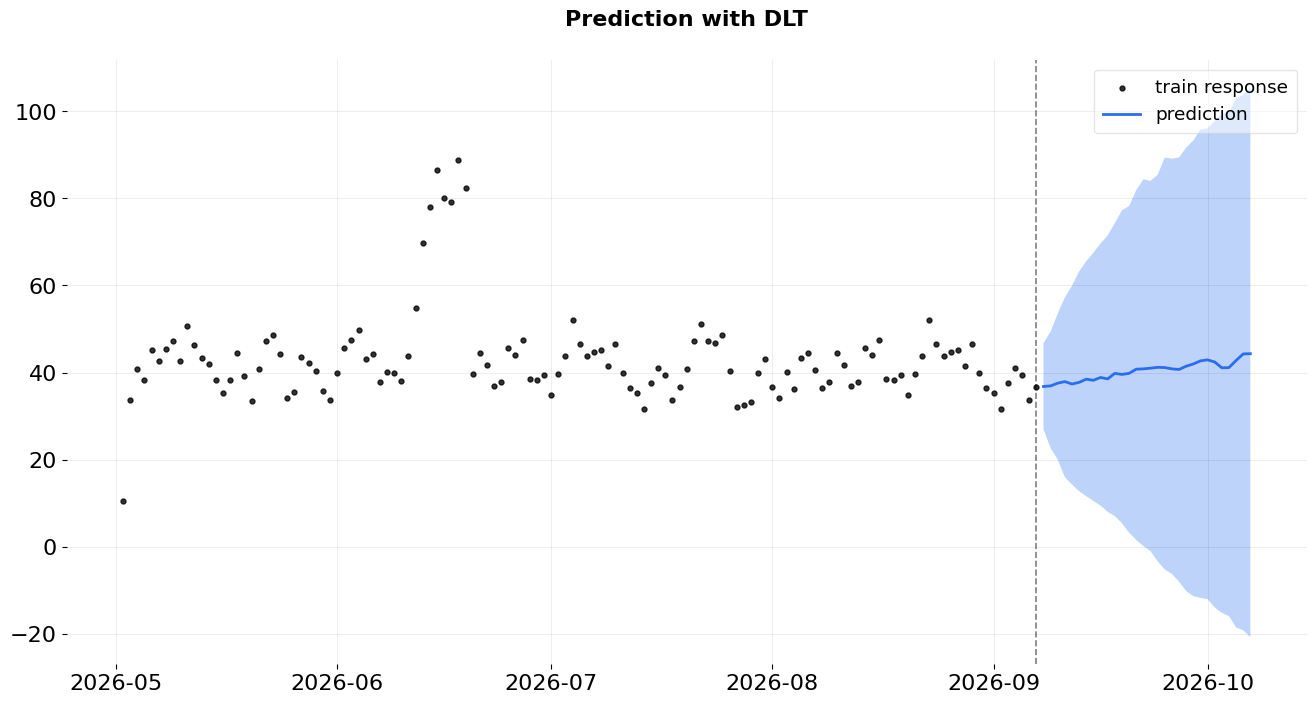

In [31]:
predicted_df_reg = with_reg_model.predict(df=future_df)
_ = plot_predicted_data(df,
                        predicted_df_reg,
                        "date", 
                        'actions_per_user', 
                        title='Prediction with DLT')

In [32]:
with_reg_model.fit_wbic(df=df)
with_reg_model.get_wbic()

2026-09-08 12:54:22 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 4.860, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

857.3076983714063

#### Модель с добавлением регрессора о флешмобе

In [33]:
df['is_flashmob'] = ((df['date'] >= '2026-06-12') & (df['date'] <= '2026-06-18')).astype(int)

In [34]:
df.query("date >= '2026-06-12' & date <= '2026-06-18'")

,date,views,actions,likes,DAU,unique_posts,posts_per_user,actions_per_user,day,is_weekend,is_flashmob
41,2026-06-12,672158,814364,142206,14829,243,45.327264,54.916987,4,0,1
42,2026-06-13,885799,1082642,196843,15526,241,57.052621,69.730903,5,1,1
43,2026-06-14,1015529,1236421,220892,15867,280,64.002584,77.924056,6,1,1
44,2026-06-15,1166286,1415092,248806,16341,282,71.371764,86.597638,0,0,1
45,2026-06-16,1090531,1320575,230044,16469,289,66.217196,80.185500,1,0,1
46,2026-06-17,1085231,1315324,230093,16632,286,65.249579,79.083935,2,0,1
47,2026-06-18,1224097,1481844,257747,16705,319,73.277282,88.706615,3,0,1


In [35]:
reg_model_2 = DLT(response_col="actions_per_user",
                date_col="date", 
                estimator="stan-mcmc",
                num_warmup=2000,
                num_sample=1000, 
                regressor_col=["is_weekend", "day", "is_flashmob"]
               )

In [36]:
reg_model_2.fit(df)

2026-09-08 12:54:26 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [37]:
future_df_reg_2 = reg_model_2.make_future_df(periods=30)
future_df_reg_2['day'] = future_df_reg_2['date'].dt.weekday
future_df_reg_2['is_weekend'] = future_df_reg_2['day'].apply(lambda x: 1 if x in [5,6] else 0)
future_df_reg_2['is_flashmob'] = 0

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

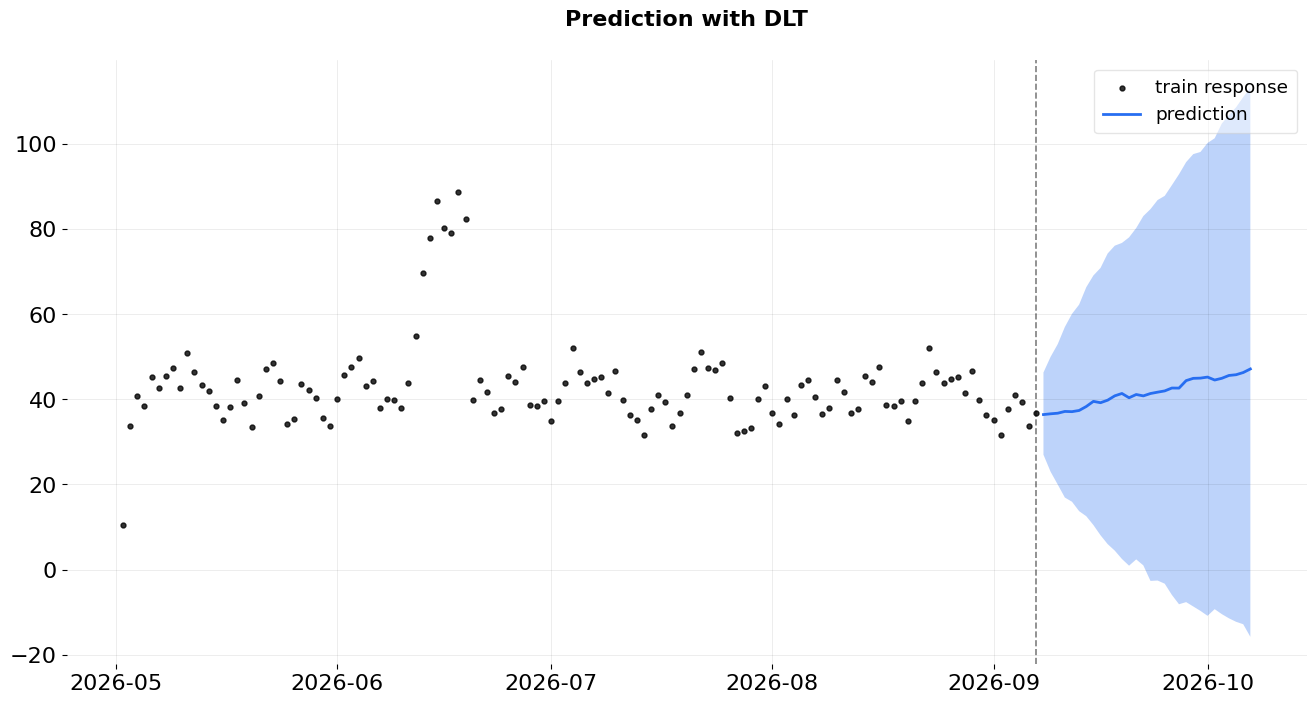

In [38]:
predicted_df_reg_2 = reg_model_2.predict(df=future_df_reg_2)
_ = plot_predicted_data(df,
                        predicted_df_reg_2,
                        "date", 
                        'actions_per_user', 
                        title='Prediction with DLT')

In [39]:
reg_model_2.fit_wbic(df=df)
reg_model_2.get_wbic()

2026-09-08 12:54:29 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 4.860, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

856.4262677156249

#### Модель с разделением выборки на тестовую и тренировочную

Тут модель больше не про предсказание, а про то, чтобы сравнить, если мы обучим модель на тренировочной выборке, насколько предсказания модели будут отличаться от реальных данных. 

In [40]:
train_df = df.query("date <= '2026-06-10'")
test_df = df.query("date > '2026-06-10'")

In [41]:
reg_model = DLT(response_col="actions_per_user",
                date_col="date", 
                estimator="stan-map", # алгоритм map
                n_bootstrap_draws=1000, 
                regressor_col=["is_weekend", "day", "is_flashmob"]
               )

2026-09-08 12:54:33 - orbit - INFO - Optimizing (PyStan) with algorithm: LBFGS.


In [42]:
reg_model.fit(train_df)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

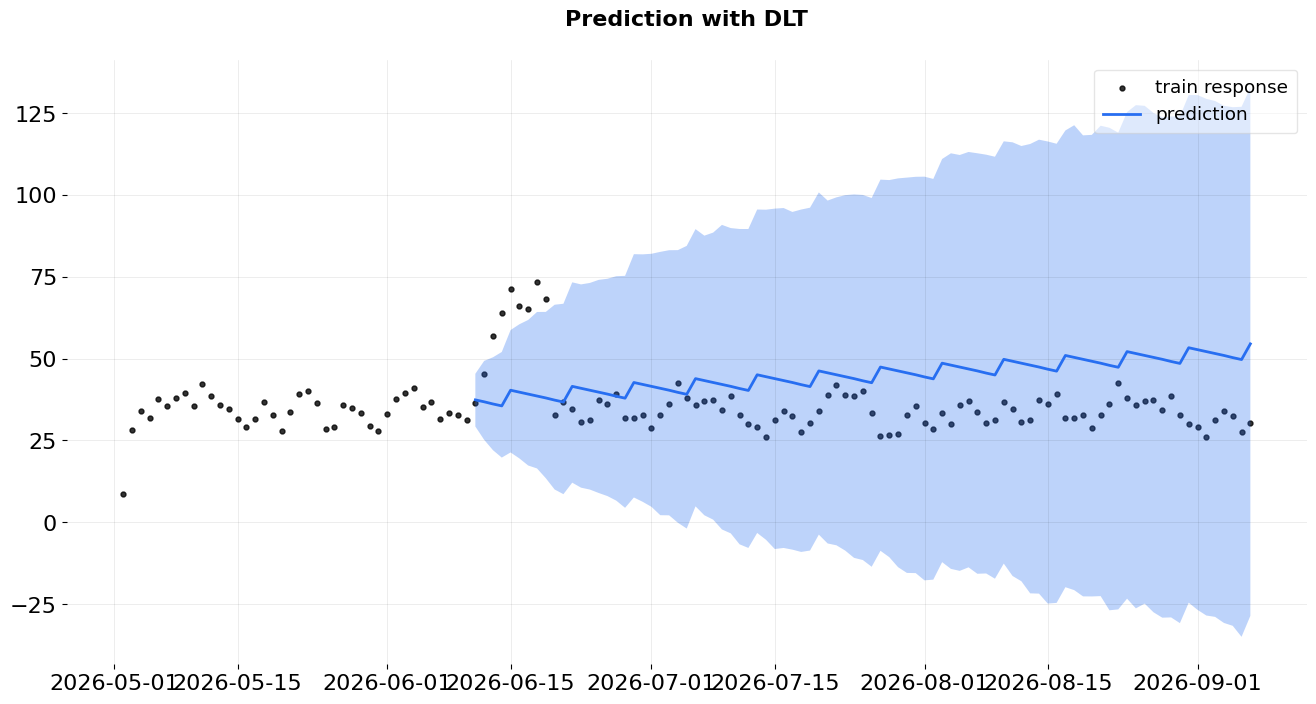

In [43]:
predicted_df = reg_model.predict(df=test_df)
_ = plot_predicted_data(df,
                        predicted_df,
                        "date", 
                        'posts_per_user', 
                        title='Prediction with DLT') 

In [44]:
reg_model.get_bic()

280.6143781074261

#### С регуляризацией

In [45]:
reg_model_auto = DLT(response_col="actions_per_user",
                date_col="date",
                estimator="stan-mcmc", # алгоритм map
                num_warmup=2000,
                num_sample=1000, 
                regressor_col=["is_weekend", "day", "is_flashmob"],
                regression_penalty="auto_ridge"
               )

In [46]:
reg_model_auto.fit(df)

2026-09-08 12:54:35 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [47]:
future_df_auto = reg_model_auto.make_future_df(periods=30)
future_df_auto['day'] = future_df_auto['date'].dt.weekday
future_df_auto['is_weekend'] = future_df_auto['day'].apply(lambda x: 1 if x in [5,6] else 0)
future_df_auto['is_flashmob'] = 0

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

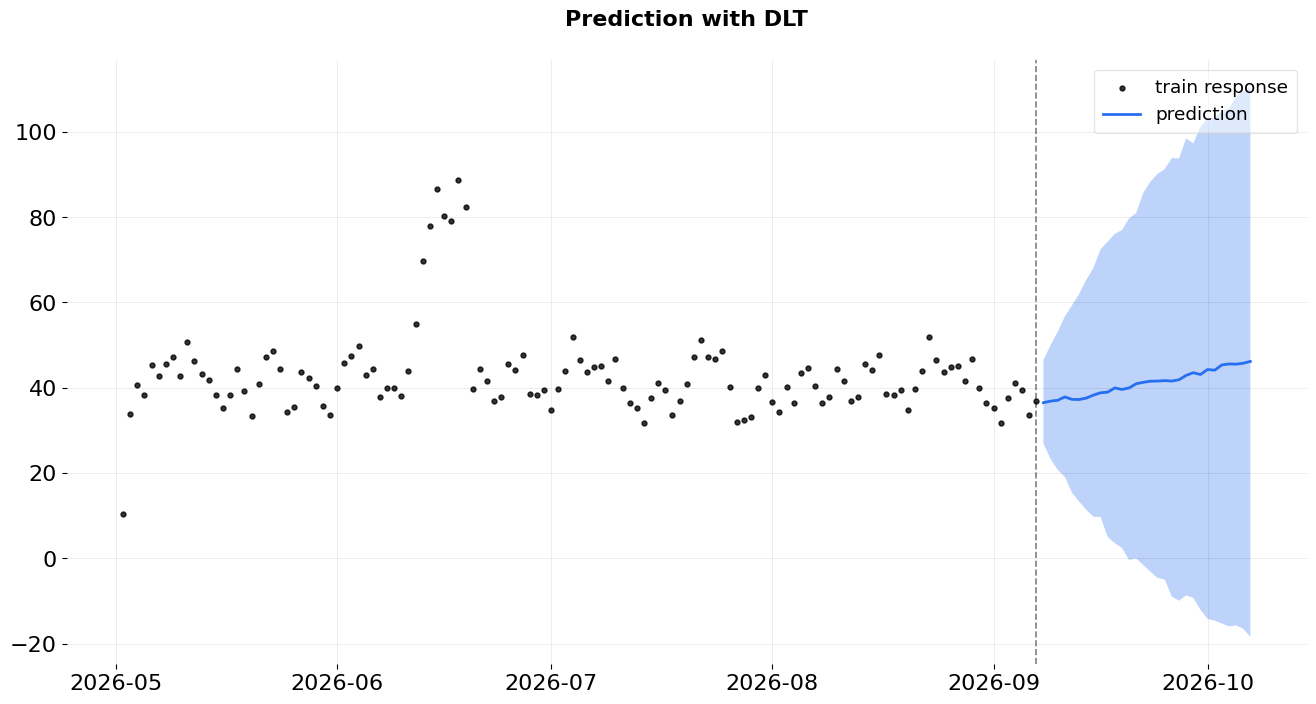

In [48]:
predicted_df_auto = reg_model_auto.predict(df=future_df_auto)
_ = plot_predicted_data(df,
                        predicted_df_auto,
                        "date", 
                        'actions_per_user', 
                        title='Prediction with DLT')

In [49]:
reg_model_auto.fit_wbic(df=df)
reg_model_auto.get_wbic()

2026-09-08 12:54:42 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 4.860, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

858.2550266212502

#### Оценка качества моделей

In [50]:
dlt.get_bic()

865.2863831670354

In [51]:
dlt_mcmc.fit_wbic(df=df)
dlt_mcmc.get_wbic()

2026-09-08 12:54:48 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 4.860, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

852.14102260125

In [52]:
with_reg_model.fit_wbic(df=df)
with_reg_model.get_wbic()

2026-09-08 12:54:52 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 4.860, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

856.6757314228125

In [53]:
reg_model_2.fit_wbic(df=df)
reg_model_2.get_wbic()

# модель с тремя регрессорами

2026-09-08 12:54:55 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 4.860, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

857.9307693792188

In [54]:
reg_model_auto.fit_wbic(df=df)
reg_model_auto.get_wbic()

# модель с регуляризацией

2026-09-08 12:54:57 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 4.860, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

857.3097816407811

(Если несколько раз проверять значения информационных критериев, значения почему-то всегда разные). Но нельзя сказать, что значения информационного критерия сильно отличаются при добавлении регрессоров, регуляризации. Тем не менее, он наименьший при алгоритме MCMC без добавления регрессии. В ней же указывалось предположение о том, что у нас недельная сезонность. В других моделях такого предположния не было. Близкой по значению информационного критерия является модель с регуляризацией. На следующем этапе попробую добавить в нее damped_factor.

2. Хватает ли у нас данных для бэктестинга с текущей задачей? 

Так как временное разрешение по дням, то всего у нас в доступе 75 дней данных. Нам не хватает данных для прогнозирования на 30 дней вперед. При этом сильно растут значения ошибок MSE (особенно он), MAE, RMSSE. При увеличении минимального объема тренировочных данных, можно сделать прогноз на 14 дней, но все равно высокий уровень среднеквадратичной ошибки. Наиболее оптимально сделать прогноз на 7 дней. В случае, если делать его на больше дней, растет и его неточность при имеющемся у нас объеме данных. 

In [55]:
from orbit.diagnostics.backtest import BackTester

# для демонстрации попыток сделать прогноз на 14 дней
bt_roll_0 = BackTester(
    model=reg_model_auto,
    df=df, 
    min_train_len=60,
    incremental_len=14, #на сколько происходит прирост тренировочных данных
    forecast_len=14, #горизонт прогнозирования
    window_type="rolling"
)

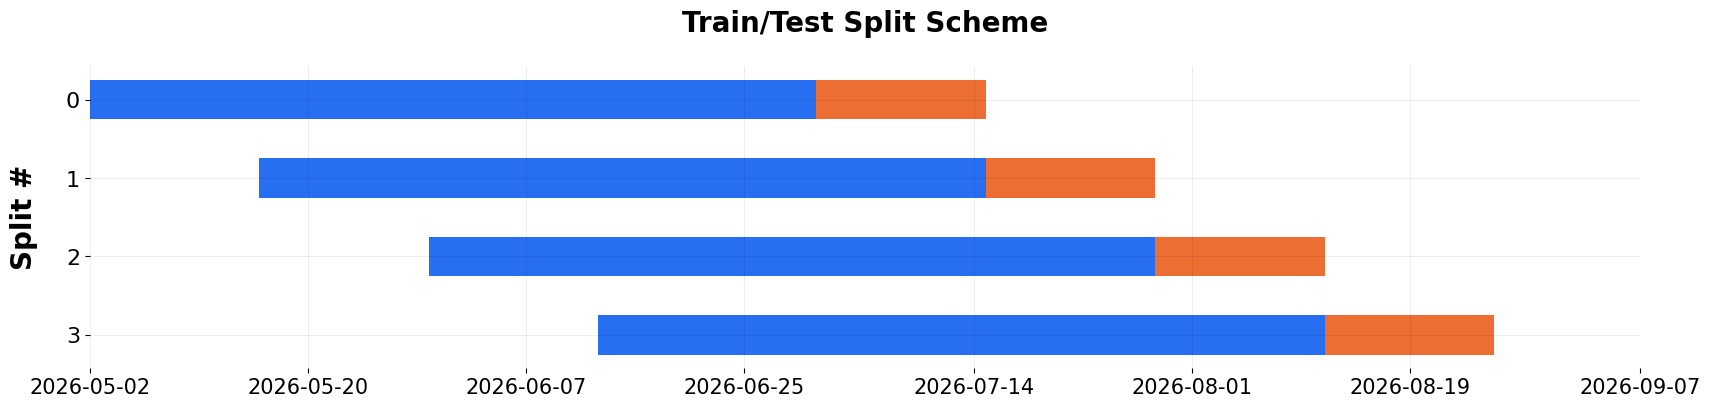

In [56]:
bt_roll_0.plot_scheme()

In [57]:
bt_roll_0.fit_predict()
bt_roll_0.score()

2026-09-08 12:55:04 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

,metric_name,metric_values,is_training_metric
0,smape,0.154637,False
1,wmape,0.150606,False
2,mape,0.152069,False
3,mse,59.123362,False
4,mae,6.180100,False
5,rmsse,1.637020,False


In [58]:
from orbit.diagnostics.backtest import BackTester

bt_roll = BackTester(
    model=reg_model_auto,
    df=df, 
    min_train_len=60,
    incremental_len=7, #на сколько происходит прирост тренировочных данных
    forecast_len=7, #горизонт прогнозирования
    window_type="rolling"
)

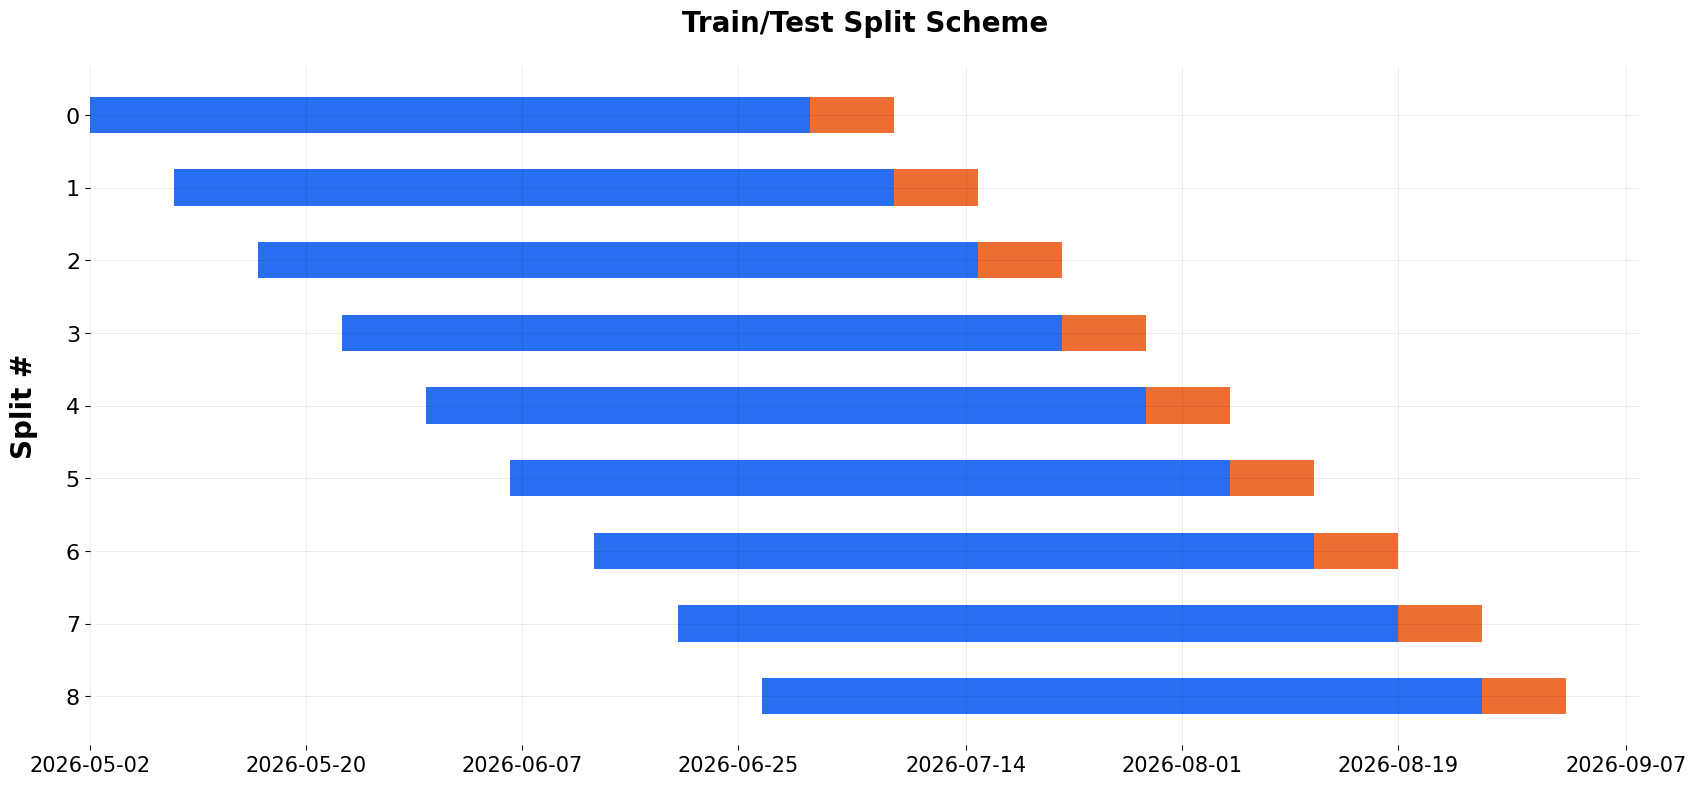

In [59]:
bt_roll.plot_scheme()

In [60]:
bt_roll.fit_predict()
bt_roll.score()

2026-09-08 12:55:18 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

,metric_name,metric_values,is_training_metric
0,smape,0.136616,False
1,wmape,0.135953,False
2,mape,0.142081,False
3,mse,54.493270,False
4,mae,5.583746,False
5,rmsse,1.604558,False


In [61]:
bt_roll_2 = BackTester(
    model=reg_model_auto,
    df=df, 
    min_train_len=60,
    incremental_len=14, #на сколько происходит прирост тренировочных данных
    forecast_len=7, #горизонт прогнозирования
    window_type="rolling"
)

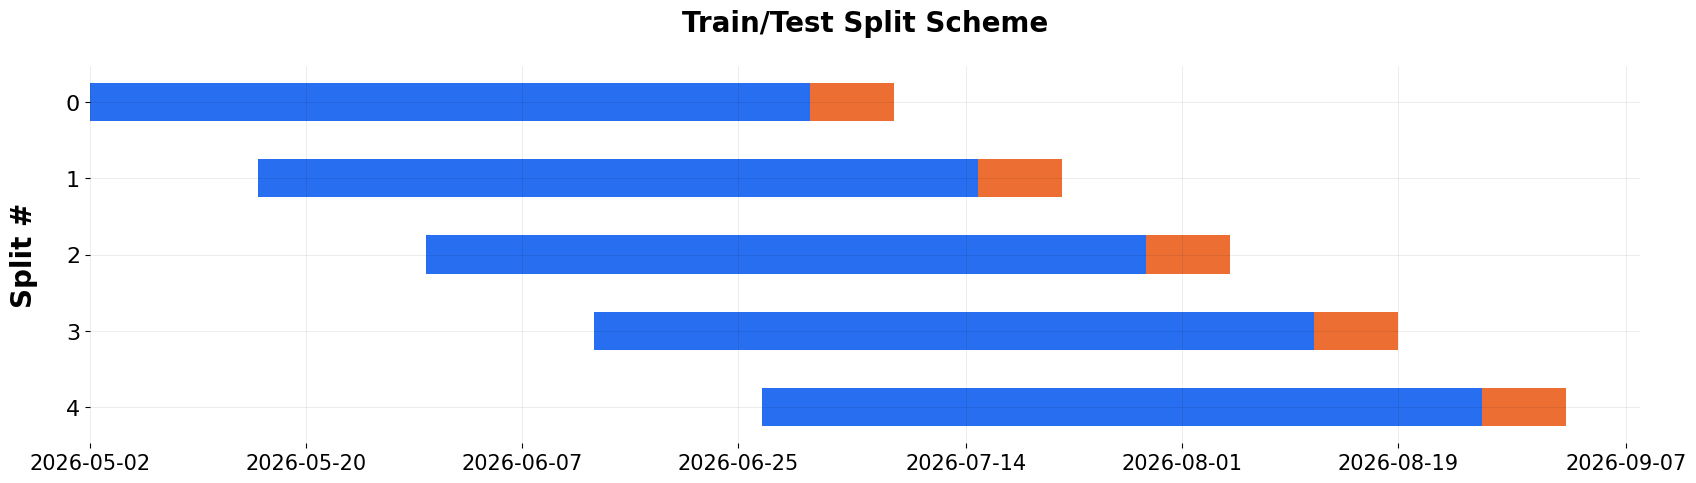

In [62]:
bt_roll_2.plot_scheme()

In [63]:
bt_roll_2.fit_predict()
bt_roll_2.score()

2026-09-08 12:55:47 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

,metric_name,metric_values,is_training_metric
0,smape,0.135213,False
1,wmape,0.128498,False
2,mape,0.128628,False
3,mse,40.303054,False
4,mae,5.227113,False
5,rmsse,1.198684,False


При различном наборе параметров получилось, что уровень ошибок самый низкий в последнем случае - при большем начальном объеме тренировочных данных и при большем приросте тренировочных данных. При этом происходит только один этап разделения. Для подбора параметров используем именно последний случай.

In [64]:
import numpy as np
from orbit.utils.params_tuning import grid_search_orbit

best_params, tuned_df = grid_search_orbit(param_grid={"damped_factor": np.arange(0.1, 1.0, 0.1)}, #наш параметр
                                        model=reg_model_auto,
                                        df=df,
                                        min_train_len=60,
                                        incremental_len=14,
                                        forecast_len=7,
                                        metrics=None, #смотрим smape по умолчанию
                                        criteria="min", #говорим, что нам нужна минимизация
                                        verbose=True) #пусть печатает процесс выполнения

  0%|          | 0/9 [00:00<?, ?it/s]

2026-09-08 12:56:02 - orbit - INFO - tuning hyper-params {'damped_factor': 0.1}
2026-09-08 12:56:02 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

2026-09-08 12:59:17 - orbit - INFO - tuning metric:0.14597


In [65]:
tuned_df

,damped_factor,metrics
0,0.1,0.110817
1,0.2,0.112627
2,0.3,0.114673
3,0.4,0.122322
4,0.5,0.126440
5,0.6,0.128915
6,0.7,0.135723
7,0.8,0.146744
8,0.9,0.145968


In [66]:
best_params

[{'damped_factor': 0.1}]

In [67]:
reg_model_auto = DLT(response_col="actions_per_user",
                date_col="date",
                estimator="stan-mcmc", # алгоритм map
                num_warmup=2000,
                num_sample=1000,
                regressor_col=["is_weekend", "day", "is_flashmob"],
                regression_penalty="auto_ridge",
                damped_factor=0.1
               )

In [68]:
reg_model_auto.fit(df)

2026-09-08 13:01:56 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [69]:
future_df_auto = reg_model_auto.make_future_df(periods=7)
future_df_auto['day'] = future_df_auto['date'].dt.weekday
future_df_auto['is_weekend'] = future_df_auto['day'].apply(lambda x: 1 if x in [5,6] else 0)
future_df_auto['is_flashmob'] = 0

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

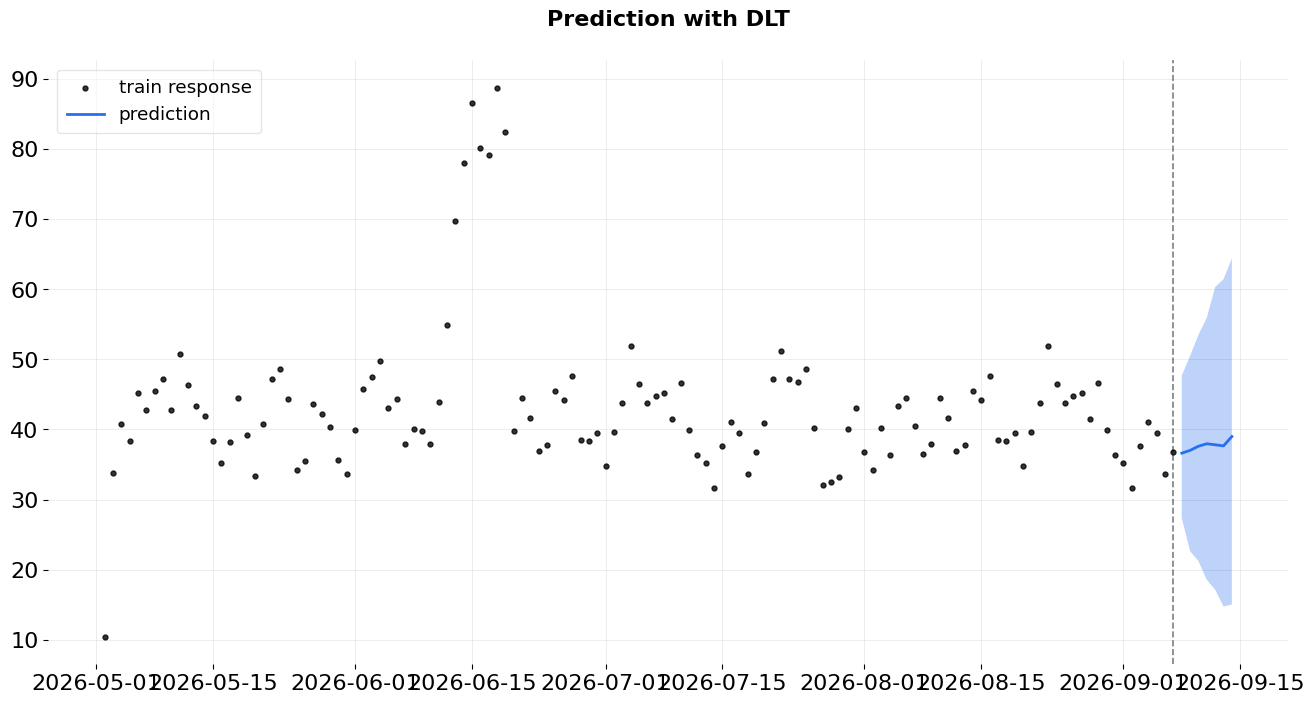

In [70]:
predicted_df_auto = reg_model_auto.predict(df=future_df_auto)
_ = plot_predicted_data(df,
                        predicted_df_auto,
                        "date", 
                        'actions_per_user', 
                        title='Prediction with DLT')

In [71]:
reg_model_auto.fit_wbic(df=df)
reg_model_auto.get_wbic()

2026-09-08 13:02:04 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 4.860, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

842.8805670843752

Ради интереса проверим еще при другом соотношении min_train_len, incremental_len, forecast_len лучшее значение параметра damped_factor и предсказание на 14 дней.

In [72]:
best_params_2, tuned_df_2 = grid_search_orbit(param_grid={"damped_factor": np.arange(0.1, 1.0, 0.1)}, #наш параметр
                                        model=reg_model_auto,
                                        df=df,
                                        min_train_len=60,
                                        incremental_len=14,
                                        forecast_len=14,
                                        metrics=None, #смотрим smape по умолчанию
                                        criteria="min", #говорим, что нам нужна минимизация
                                        verbose=True) #пусть печатает процесс выполнения

  0%|          | 0/9 [00:00<?, ?it/s]

2026-09-08 13:02:11 - orbit - INFO - tuning hyper-params {'damped_factor': 0.1}
2026-09-08 13:02:11 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

2026-09-08 13:04:37 - orbit - INFO - tuning metric:0.1854


In [73]:
best_params_2

[{'damped_factor': 0.2}]

In [79]:
reg_model_auto_2 = DLT(response_col="actions_per_user",
                date_col="date",
                estimator="stan-mcmc", # алгоритм map
                num_warmup=2000,
                num_sample=1000,
                regressor_col=["is_weekend", "day", "is_flashmob"],
                regression_penalty="auto_ridge",
                damped_factor=0.2
               )

In [80]:
reg_model_auto_2.fit(df)

2026-09-08 13:06:27 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 1.000, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

In [81]:
future_df_auto_2 = reg_model_auto_2.make_future_df(periods=14)
future_df_auto_2['day'] = future_df_auto_2['date'].dt.weekday
future_df_auto_2['is_weekend'] = future_df_auto_2['day'].apply(lambda x: 1 if x in [5,6] else 0)
future_df_auto_2['is_flashmob'] = 0

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

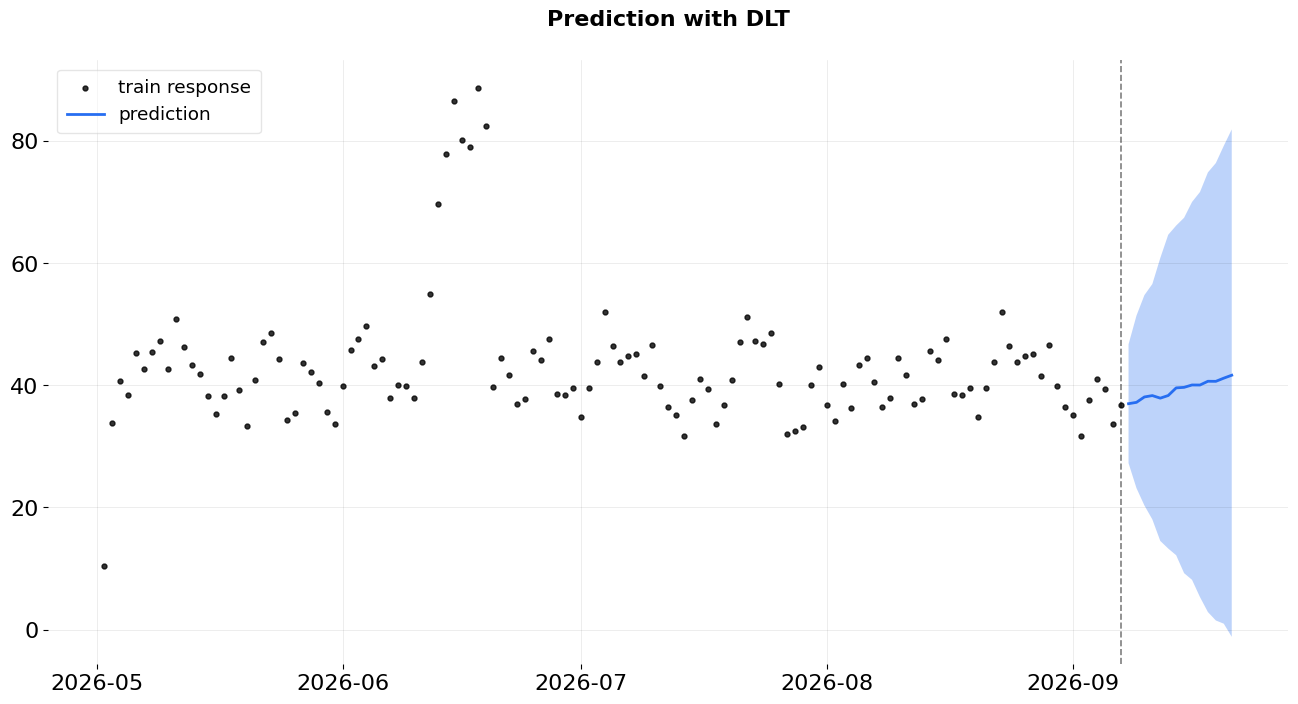

In [82]:
predicted_df_auto_2 = reg_model_auto.predict(df=future_df_auto_2)
_ = plot_predicted_data(df,
                        predicted_df_auto_2,
                        "date", 
                        'actions_per_user', 
                        title='Prediction with DLT')

In [83]:
reg_model_auto_2.fit_wbic(df=df)
reg_model_auto_2.get_wbic()

2026-09-08 13:06:34 - orbit - INFO - Sampling (PyStan) with chains: 4, cores: 8, temperature: 4.860, warmups (per chain): 500 and samples(per chain): 250.


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

842.3993909971875

При добавлении параметра информационный критерий снижается. Неудобство в том, что при подборе параметров и многоразовом запуске моделей информационный критерий снижается, а некоторые результаты постоянно меняются, что создает сложность для анализа (возможно, модель постоянно переобучается на имеющихся данных).

Вывод: самой лучшей является модель с добавлением параметра damped_factor, регуляризацией и регрессорами. Предсказания на длительный период при имеющемся объеме данных не будут точными, если пытаться спрогнозировать на очень длительный период, поэтому были рассмотрены только предсказания на 7 и 14 дней вперед. Везде предполагается умереннаыя восходящая динамика. Информация о грядущих флешмобах или других мероприятиях, которые могли бы повлиять на резкий рост активности пользователей и, следовательно, нагрузки на платформу, отсутствует. Прогноз предполагает незначительный рост. В случае проведения каких-либо мероприятий резкий рост возможен, их бы можно было учесть в модели в качестве регрессоров в случае наличия такой информации. Для предсказаний в модели построен довольно широкий доверительный интервал, то есть предполагается возможный большой разброс значений.